# Project 02: Iris Flower Classification

## Step 1: Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

## Step 2: Load Dataset

In [8]:
import pandas as pd
df=pd.read_csv('/content/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


The Iris dataset was loaded successfully. The first five records were displayed to understand the structure of the dataset.

## Step 3: Dataset Exploration

### Checking Dataset Shape

In [9]:
df.shape

(150, 6)

The dataset contains 150 rows and 6 columns.|

### Checking Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


The dataset contains numerical and categorical data types. The Species column is the target variable.

### Checking Missing Values

In [11]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


No missing values were found in the dataset.

### Statistical Summary

In [12]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


The statistical summary provides information about the distribution of numerical features such as mean, minimum, maximum, and standard deviation.

## Dataset Summary

1. The dataset contains 150 flower records.
2. It includes measurements of sepal and petal dimensions.
3. The target variable is Species.
4. The dataset contains three flower species.
5. No missing values were found in the dataset.

## Step 4: Data Preprocessing

### Encoding Target Variable

In [13]:
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


The Species column was converted from text labels into numerical values so that machine learning algorithms can process it.

### Removing Irrelevant Column

In [14]:
df.drop('Id',axis=1,inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


The Id column was removed because it does not contribute to predicting flower species.

### Defining Features and Target Variable

In [15]:
X=df.drop('Species',axis=1)
y=df['Species']

Feature variables were separated from the target variable for model training.

### Splitting Dataset into Training and Testing Sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


The dataset was split into 80% training data and 20% testing data as required by the project guidelines.

## Step 5: Feature Engineering

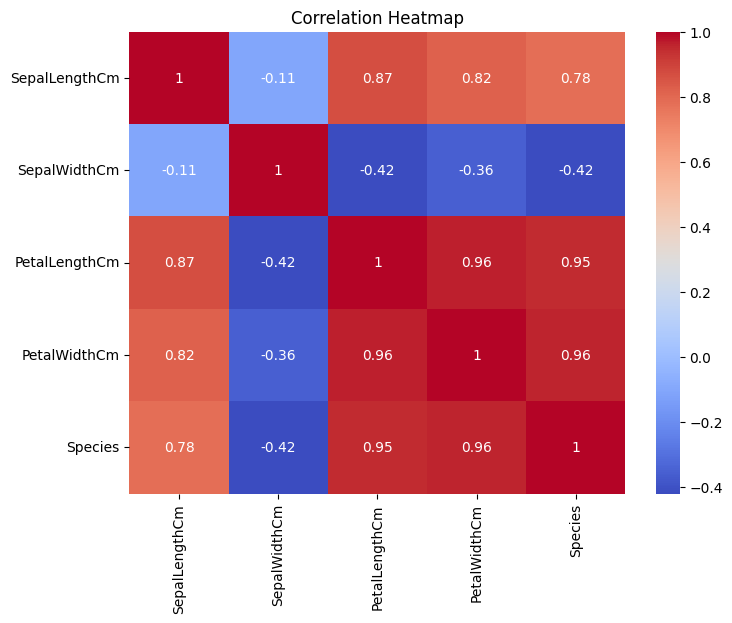

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

The heatmap shows the relationships between numerical features. Petal Length and Petal Width have a strong positive correlation, indicating they are closely related.

## Step 6: Train Machine Learning Models

### Logistic Regression Model


In [18]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

The Logistic Regression model was trained successfully and predictions were generated on the test dataset.

### K-Nearest Neighbors (KNN) Model

In [19]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
knn_pred=knn.predict(X_test)


The KNN model was trained successfully and predictions were generated for the test dataset

### Random Forest Model

In [20]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)


The Random Forest model was trained successfully and predictions were generated for the test dataset.

## Step 7: Model Evaluation and Comparison

According to the project guidelines, all three machine learning models must be evaluated using proper classification metrics such as Accuracy, Precision, Recall, and F1 Score. These metrics help compare the performance of each model clearly.

In [22]:
# Evaluating Logistic Regression model
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

# Evaluating KNN model
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

# Evaluating Random Forest model
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

The performance metrics for all three models were calculated. Accuracy shows the overall correct predictions, Precision shows the correctness of positive predictions, Recall shows how well actual classes were identified, and F1 Score gives a balanced performance value.

In [23]:
# Creating a comparison table for all models
comparison_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest'],
    'Accuracy': [lr_accuracy, knn_accuracy, rf_accuracy],
    'Precision': [lr_precision, knn_precision, rf_precision],
    'Recall': [lr_recall, knn_recall, rf_recall],
    'F1 Score': [lr_f1, knn_f1, rf_f1]
})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,KNN,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


The comparison table shows the performance of Logistic Regression, KNN, and Random Forest models. This table helps identify which model performed best based on Accuracy, Precision, Recall, and F1 Score.

In [24]:
# Finding the best model based on highest accuracy
best_model = comparison_table.loc[comparison_table['Accuracy'].idxmax()]
best_model

,0
Model,Logistic Regression
Accuracy,1.0
Precision,1.0
Recall,1.0
F1 Score,1.0


Based on the comparison table, the model with the highest accuracy was selected as the best performing model for Iris Flower Classification.

## Step 8: Confusion Matrix for Best Model

A confusion matrix is used to show how many flower species were correctly and incorrectly classified by the best model.

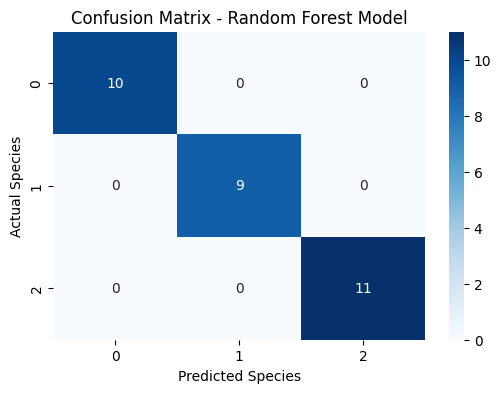

In [25]:
# Confusion matrix for Random Forest model
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix - Random Forest Model')
plt.show()

The confusion matrix shows the number of correct and incorrect predictions made by the Random Forest model. Most predictions were classified correctly, which shows that the model performed well on the test dataset.

## Step 9: Best Model Analysis and Conclusion

1. In this project, the Iris dataset was used to classify flowers into different species.
2. The dataset was preprocessed by encoding the Species column and removing the irrelevant Id column.
3. Three machine learning models were trained: Logistic Regression, KNN, and Random Forest.
4. The models were evaluated using Accuracy, Precision, Recall, and F1 Score.
5. Based on the comparison results and confusion matrix, the best performing model was selected for Iris Flower Classification.